In [34]:
pip install statsmodels scikit-learn seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import itertools
import math

In [37]:
total_data = pd.read_csv("../data/total_visitor_arrivals_monthly.csv")
total_data["month"] = pd.to_datetime(total_data["month"])
print(total_data.shape)
total_data.head()

(569, 2)


,month,total_visitor_arrivals
0,1978-01-01,165678.0
1,1978-02-01,163401.0
2,1978-03-01,166743.0
3,1978-04-01,167155.0
4,1978-05-01,169163.0


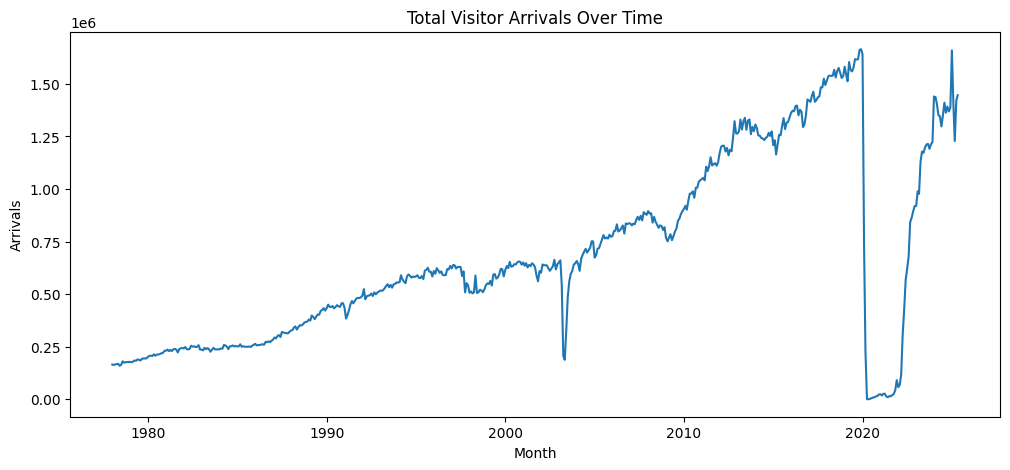

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(total_data["month"], total_data["total_visitor_arrivals"])
plt.title("Total Visitor Arrivals Over Time")
plt.xlabel("Month")
plt.ylabel("Arrivals")
plt.show()

In [39]:
total_data["total_log_arrivals"] = np.log1p(total_data["total_visitor_arrivals"])

result = adfuller(total_data["total_log_arrivals"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.6276675689188433
p-value: 0.005253587987381165


In [40]:
total_data["diff_1"] = total_data["total_log_arrivals"].diff()
adfuller_result_diff_1 = adfuller(total_data["diff_1"].dropna())
print("ADF Statistic:", adfuller_result_diff_1[0])
print("p-value:", adfuller_result_diff_1[1])

ADF Statistic: -14.749669922198635
p-value: 2.4963666494265416e-27


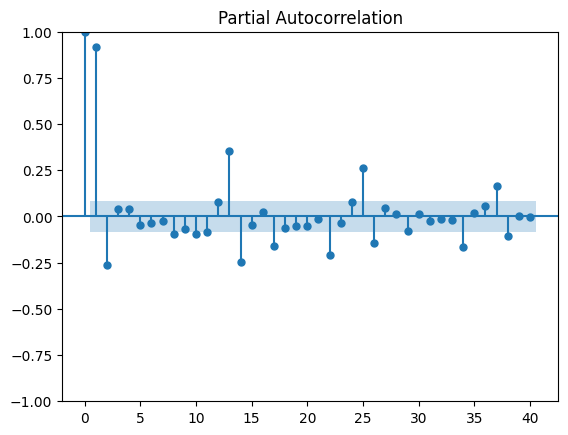

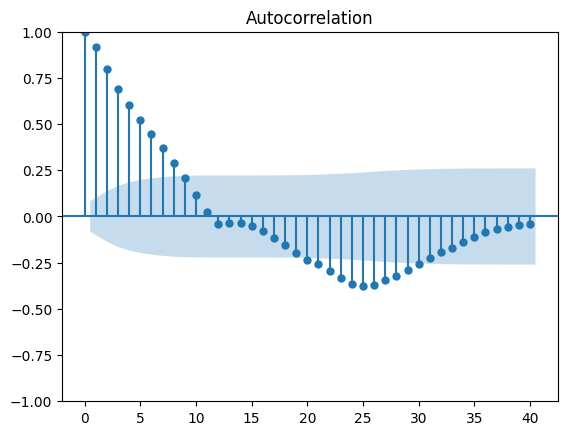

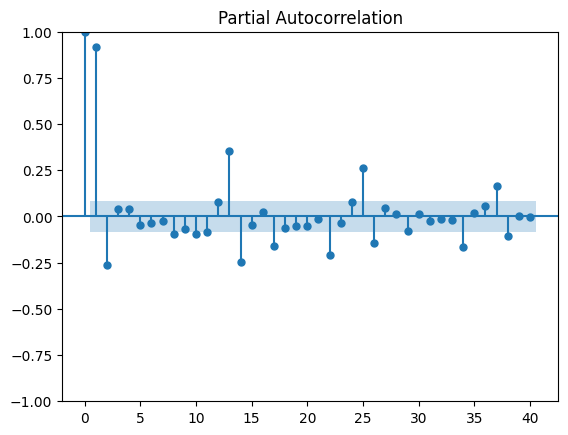

In [41]:
total_data["diff_12"] = total_data["total_log_arrivals"].diff(12)

plot_acf(total_data["diff_12"].dropna(), lags=40)
plot_pacf(total_data["diff_12"].dropna(), lags=40)

In [42]:
# Arima
model = ARIMA(total_data["total_log_arrivals"], order=(1,1,1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:     total_log_arrivals   No. Observations:                  569
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -51.916
Date:                Sun, 12 Apr 2026   AIC                            109.833
Time:                        22:04:42   BIC                            122.859
Sample:                             0   HQIC                           114.916
                                - 569                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0992      0.062      1.592      0.111      -0.023       0.221
ma.L1          0.1479      0.065      2.288      0.022       0.021       0.275
sigma2         0.0703      0.000    153.615      0.0

In [54]:
train = total_data[:-24]
test = total_data[-24:]

print(len(total_data))
print(len(train))
print(len(test))

569
545
24


In [44]:
p = q = range(0, 3)
d = [1]

P = Q = range(0, 2)
D = [1]
s = [12]

results = []

for order in itertools.product(p, d, q):
    for seasonal_order_base in itertools.product(P, D, Q, s):
        try:
            model = SARIMAX(
                train["total_log_arrivals"],
                order=order,
                seasonal_order=seasonal_order_base,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False)

            pred = fitted.get_forecast(steps=len(test)).predicted_mean
            rmse = np.sqrt(mean_squared_error(test["total_log_arrivals"], pred))

            results.append({
                "order": order,
                "seasonal_order": seasonal_order_base,
                "aic": fitted.aic,
                "bic": fitted.bic,
                "rmse_log": rmse
            })

        except Exception:
            continue

results_df = pd.DataFrame(results).sort_values(by=["rmse_log", "aic"])
results_df.head(10)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,aic,bic,rmse_log
25,"(2, 1, 0)","(0, 1, 1, 12)",173.794382,190.801998,0.085248
5,"(0, 1, 1)","(0, 1, 1, 12)",173.427504,186.177430,0.086042
17,"(1, 1, 1)","(0, 1, 1, 12)",174.833204,191.833105,0.087642
1,"(0, 1, 0)","(0, 1, 1, 12)",201.498244,210.002052,0.088067
9,"(0, 1, 2)","(0, 1, 1, 12)",174.831581,191.823752,0.089969
13,"(1, 1, 0)","(0, 1, 1, 12)",173.799928,186.555639,0.092252
27,"(2, 1, 0)","(1, 1, 1, 12)",181.812234,203.062111,0.094283
7,"(0, 1, 1)","(1, 1, 1, 12)",181.764859,198.764760,0.094719
3,"(0, 1, 0)","(1, 1, 1, 12)",210.709074,223.464785,0.094769
35,"(2, 1, 2)","(1, 1, 1, 12)",179.831866,209.568166,0.095928


In [49]:
model = SARIMAX(train["total_log_arrivals"], order=(2,1,0), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
result = model.fit()

pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.51278D-01    |proj g|=  1.04999D+00


 This problem is unconstrained.



At iterate    5    f=  1.52206D-01    |proj g|=  5.48429D-02

At iterate   10    f=  1.52105D-01    |proj g|=  6.41309D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     13     16      1     0     0   7.960D-06   1.521D-01
  F =  0.15210493769360248     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


In [50]:
rmse = np.sqrt(mean_squared_error(test["total_log_arrivals"], pred_mean))
print("RMSE:", rmse)

RMSE: 0.08524773202743045


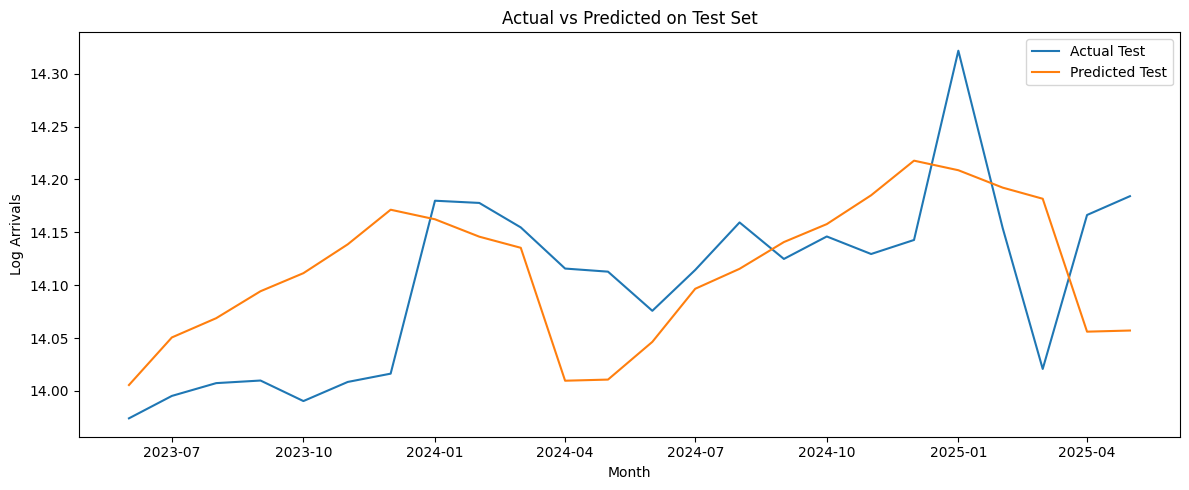

In [51]:
plt.figure(figsize=(12,5))
plt.plot(test["month"], test["total_log_arrivals"], label="Actual Test")
plt.plot(test["month"], pred_mean, label="Predicted Test")
plt.title("Actual vs Predicted on Test Set")
plt.xlabel("Month")
plt.ylabel("Log Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

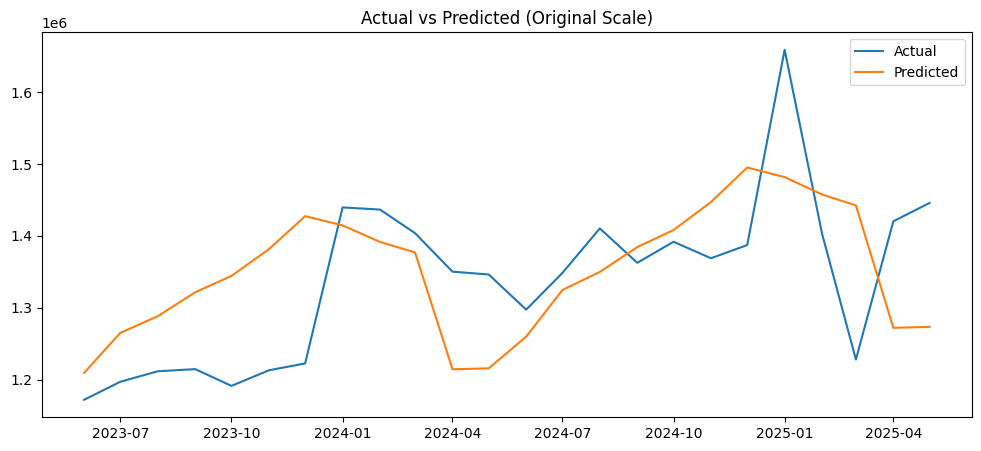

In [52]:
actual_test = np.expm1(test["total_log_arrivals"])
pred_test = np.expm1(pred_mean)

plt.figure(figsize=(12,5))
plt.plot(test["month"], actual_test, label="Actual")
plt.plot(test["month"], pred_test, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Original Scale)")
plt.show()

In [55]:
models_to_test = [
    {"name": "SARIMA_210_01112", "order": (2, 1, 0), "seasonal_order": (0, 1, 1, 12)},
    {"name": "SARIMA_011_01112", "order": (0, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"name": "SARIMA_111_01112", "order": (1, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"name": "SARIMA_010_01112", "order": (0, 1, 0), "seasonal_order": (0, 1, 1, 12)},
]

all_preds = []
model_scores = []

for config in models_to_test:
    model = SARIMAX(
        train["total_log_arrivals"],
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False)
    pred = result.get_forecast(steps=len(test))
    pred_mean = pred.predicted_mean
    
    rmse_log = np.sqrt(mean_squared_error(test["total_log_arrivals"], pred_mean))
    
    pred_original = np.expm1(pred_mean)
    actual_original = np.expm1(test["total_log_arrivals"])
    rmse_original = np.sqrt(mean_squared_error(actual_original, pred_original))
    
    model_scores.append({
        "model_name": config["name"],
        "order": config["order"],
        "seasonal_order": config["seasonal_order"],
        "aic": result.aic,
        "bic": result.bic,
        "rmse_log": rmse_log,
        "rmse_original": rmse_original
    })
    
    temp_df = pd.DataFrame({
        "month": test["month"].values,
        "actual_log": test["total_log_arrivals"].values,
        "predicted_log": pred_mean.values,
        "actual_original": actual_original.values,
        "predicted_original": pred_original.values,
        "model_name": config["name"]
    })
    
    all_preds.append(temp_df)

scores_df = pd.DataFrame(model_scores).sort_values(["rmse_log", "aic"]).reset_index(drop=True)
preds_df = pd.concat(all_preds, ignore_index=True)

display(scores_df)

,model_name,order,seasonal_order,aic,bic,rmse_log,rmse_original
0,SARIMA_210_01112,"(2, 1, 0)","(0, 1, 1, 12)",173.794382,190.801998,0.085248,114058.152067
1,SARIMA_011_01112,"(0, 1, 1)","(0, 1, 1, 12)",173.427504,186.177430,0.086042,115296.171630
2,SARIMA_111_01112,"(1, 1, 1)","(0, 1, 1, 12)",174.833204,191.833105,0.087642,117559.388630
3,SARIMA_010_01112,"(0, 1, 0)","(0, 1, 1, 12)",201.498244,210.002052,0.088067,118142.502602


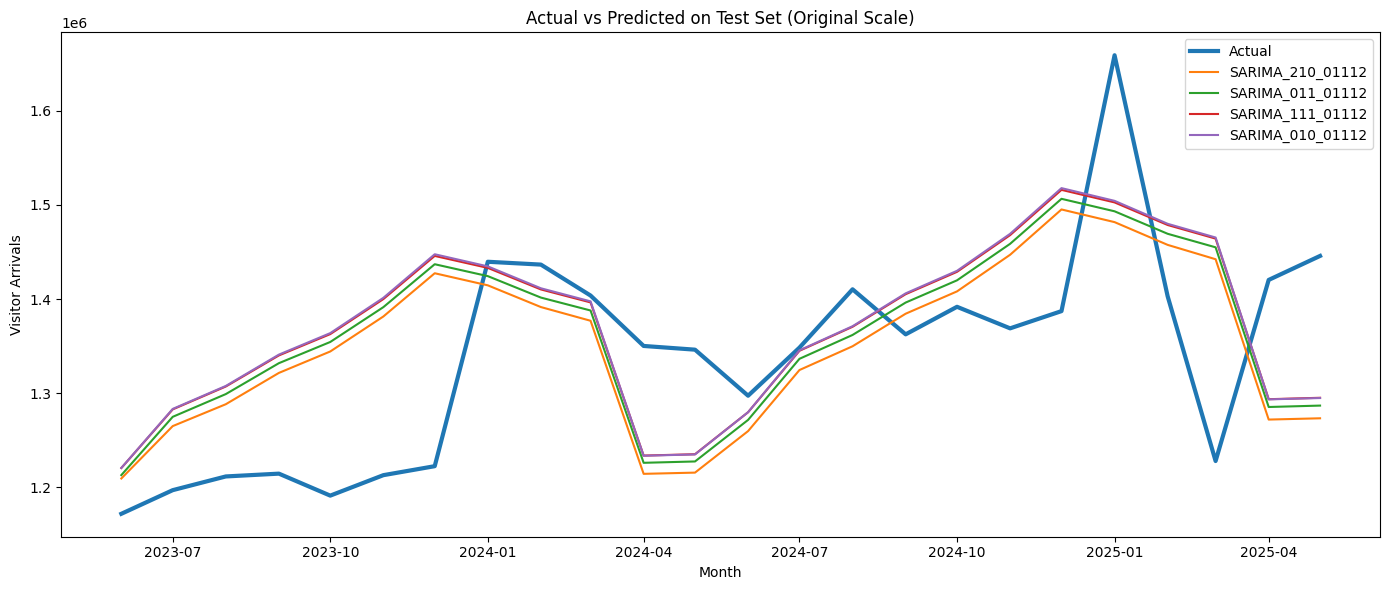

In [56]:
plt.figure(figsize=(14, 6))
plt.plot(test["month"], np.expm1(test["total_log_arrivals"]), label="Actual", linewidth=3)

for model_name in preds_df["model_name"].unique():
    plot_df = preds_df[preds_df["model_name"] == model_name]
    plt.plot(plot_df["month"], plot_df["predicted_original"], label=model_name)

plt.title("Actual vs Predicted on Test Set (Original Scale)")
plt.xlabel("Month")
plt.ylabel("Visitor Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
data = pd.read_csv("../data/visitor_prediction_features_snapshot.csv")
data["month"] = pd.to_datetime(data["month"])

data = data.sort_values(["country", "month"]).reset_index(drop=True)
data.head()

,country,month,visitor_arrivals,gdp,exchange_rate,public_holiday_count,aircraft_passengers,traffic_volume,hotel_rate,hotel_occupancy
0,Australia,1978-01-01,20379.0,135608.0,NaN,2,NaN,NaN,NaN,NaN
1,Australia,1978-02-01,18852.0,135608.0,NaN,0,NaN,NaN,NaN,NaN
2,Australia,1978-03-01,20819.0,135608.0,NaN,9,NaN,NaN,NaN,NaN
3,Australia,1978-04-01,18697.0,135608.0,NaN,1,NaN,NaN,NaN,NaN
4,Australia,1978-05-01,19797.0,135608.0,NaN,3,NaN,NaN,NaN,NaN


In [58]:
country_df = data[["country", "month", "visitor_arrivals"]].copy()

# log transform
country_df["log_arrivals"] = np.log1p(country_df["visitor_arrivals"])

country_df.head()

,country,month,visitor_arrivals,log_arrivals
0,Australia,1978-01-01,20379.0,9.922309
1,Australia,1978-02-01,18852.0,9.844427
2,Australia,1978-03-01,20819.0,9.943669
3,Australia,1978-04-01,18697.0,9.836172
4,Australia,1978-05-01,19797.0,9.893336


In [59]:
p = q = range(0, 3)
d = [1]

P = Q = range(0, 2)
D = [1]
s = [12]

all_results = []
all_predictions = []
failed_countries = []

for country_name, df_country in country_df.groupby("country"):
    df_country = df_country.sort_values("month").reset_index(drop=True).copy()
    
    # skip countries with too little data
    if len(df_country) < 36:
        failed_countries.append({
            "country": country_name,
            "reason": "Not enough data (<36 rows)"
        })
        continue
    
    # drop missing
    df_country = df_country.dropna(subset=["log_arrivals"]).copy()
    
    train = df_country.iloc[:-24].copy()
    test = df_country.iloc[-24:].copy()
    
    if len(train) < 24 or len(test) < 12:
        failed_countries.append({
            "country": country_name,
            "reason": "Train/test split too small"
        })
        continue

    country_results = []

    for order in itertools.product(p, d, q):
        for seasonal_order in itertools.product(P, D, Q, s):
            try:
                model = SARIMAX(
                    train["log_arrivals"],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False)

                pred = fitted.get_forecast(steps=len(test)).predicted_mean
                rmse_log = np.sqrt(mean_squared_error(test["log_arrivals"], pred))

                country_results.append({
                    "country": country_name,
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "aic": fitted.aic,
                    "bic": fitted.bic,
                    "rmse_log": rmse_log
                })

            except Exception:
                continue

    if len(country_results) == 0:
        failed_countries.append({
            "country": country_name,
            "reason": "All SARIMA combinations failed"
        })
        continue

    country_results_df = pd.DataFrame(country_results).sort_values(
        by=["rmse_log", "aic"]
    ).reset_index(drop=True)

    best_row = country_results_df.iloc[0]
    all_results.append(best_row.to_dict())

    # refit best model
    best_model = SARIMAX(
        train["log_arrivals"],
        order=best_row["order"],
        seasonal_order=best_row["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    best_fit = best_model.fit(disp=False)

    best_pred = best_fit.get_forecast(steps=len(test)).predicted_mean

    pred_df = pd.DataFrame({
        "country": country_name,
        "month": test["month"].values,
        "actual_log": test["log_arrivals"].values,
        "predicted_log": best_pred.values,
        "actual": np.expm1(test["log_arrivals"].values),
        "predicted": np.expm1(best_pred.values)
    })

    all_predictions.append(pred_df)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

In [60]:
best_models_df = pd.DataFrame(all_results).sort_values(["rmse_log", "aic"]).reset_index(drop=True)
predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
failed_df = pd.DataFrame(failed_countries)

print("Successful countries:", len(best_models_df))
print("Failed countries:", len(failed_df))

display(best_models_df.head(20))
display(failed_df.head(20))

Successful countries: 16
Failed countries: 0


,country,order,seasonal_order,aic,bic,rmse_log
0,United States,"(2, 1, 1)","(0, 1, 1, 12)",327.735128,348.985004,0.068276
1,New Zealand,"(1, 1, 2)","(0, 1, 1, 12)",466.763333,488.003547,0.083219
2,Netherlands,"(1, 1, 2)","(0, 1, 1, 12)",418.360268,439.600482,0.084657
3,France,"(2, 1, 2)","(0, 1, 1, 12)",380.169577,405.657834,0.100000
4,Switzerland,"(2, 1, 0)","(0, 1, 1, 12)",499.478857,516.486473,0.106873
5,Japan,"(1, 1, 0)","(0, 1, 1, 12)",307.895430,320.651142,0.129987
6,Hong Kong,"(2, 1, 2)","(0, 1, 1, 12)",356.735455,382.223713,0.135159
7,Australia,"(1, 1, 2)","(1, 1, 1, 12)",523.434148,548.922405,0.148311
8,Taiwan,"(0, 1, 0)","(0, 1, 1, 12)",469.969789,478.473597,0.156522
9,Germany,"(1, 1, 2)","(0, 1, 1, 12)",547.984574,569.224788,0.158530


""


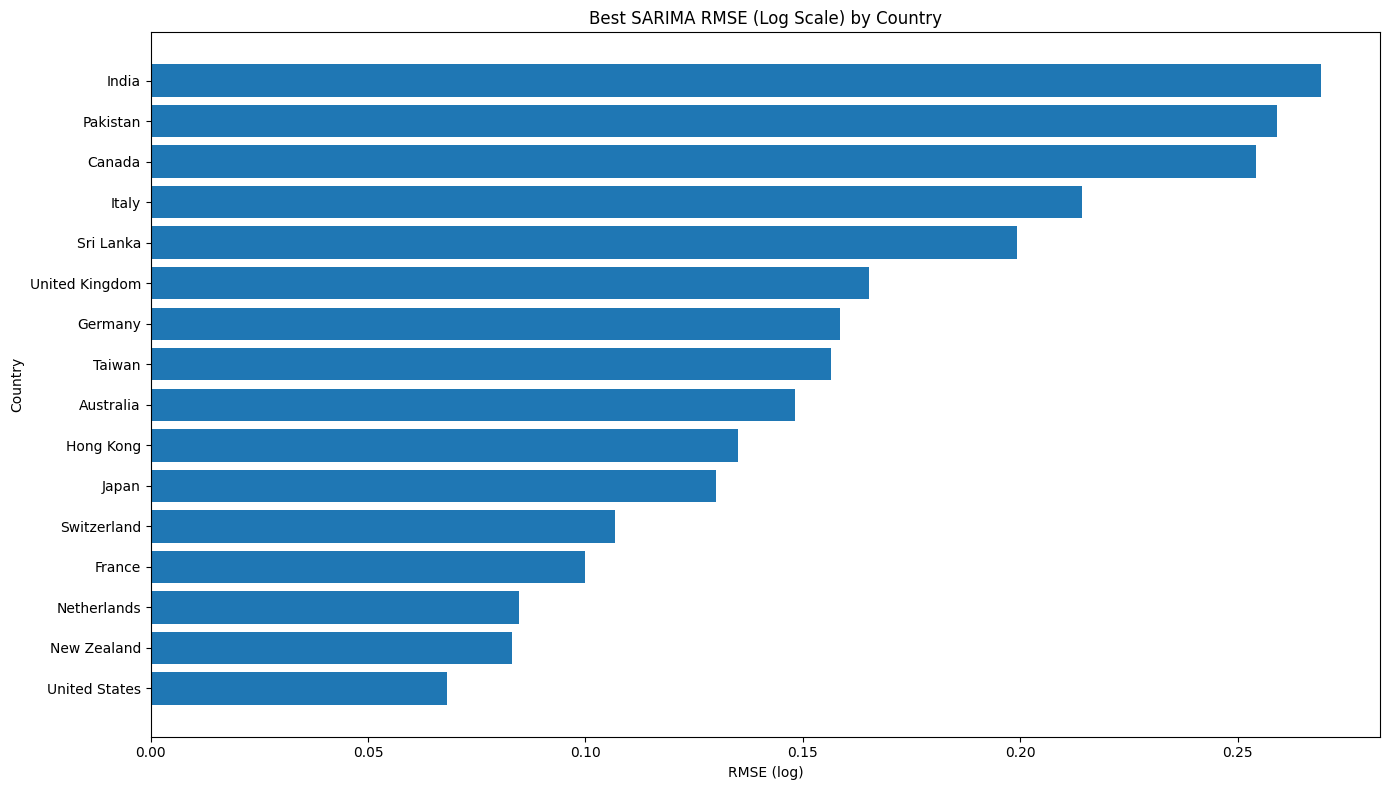

In [61]:
plt.figure(figsize=(14, 8))
best_models_df = best_models_df.sort_values("rmse_log")

plt.barh(best_models_df["country"], best_models_df["rmse_log"])
plt.title("Best SARIMA RMSE (Log Scale) by Country")
plt.xlabel("RMSE (log)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

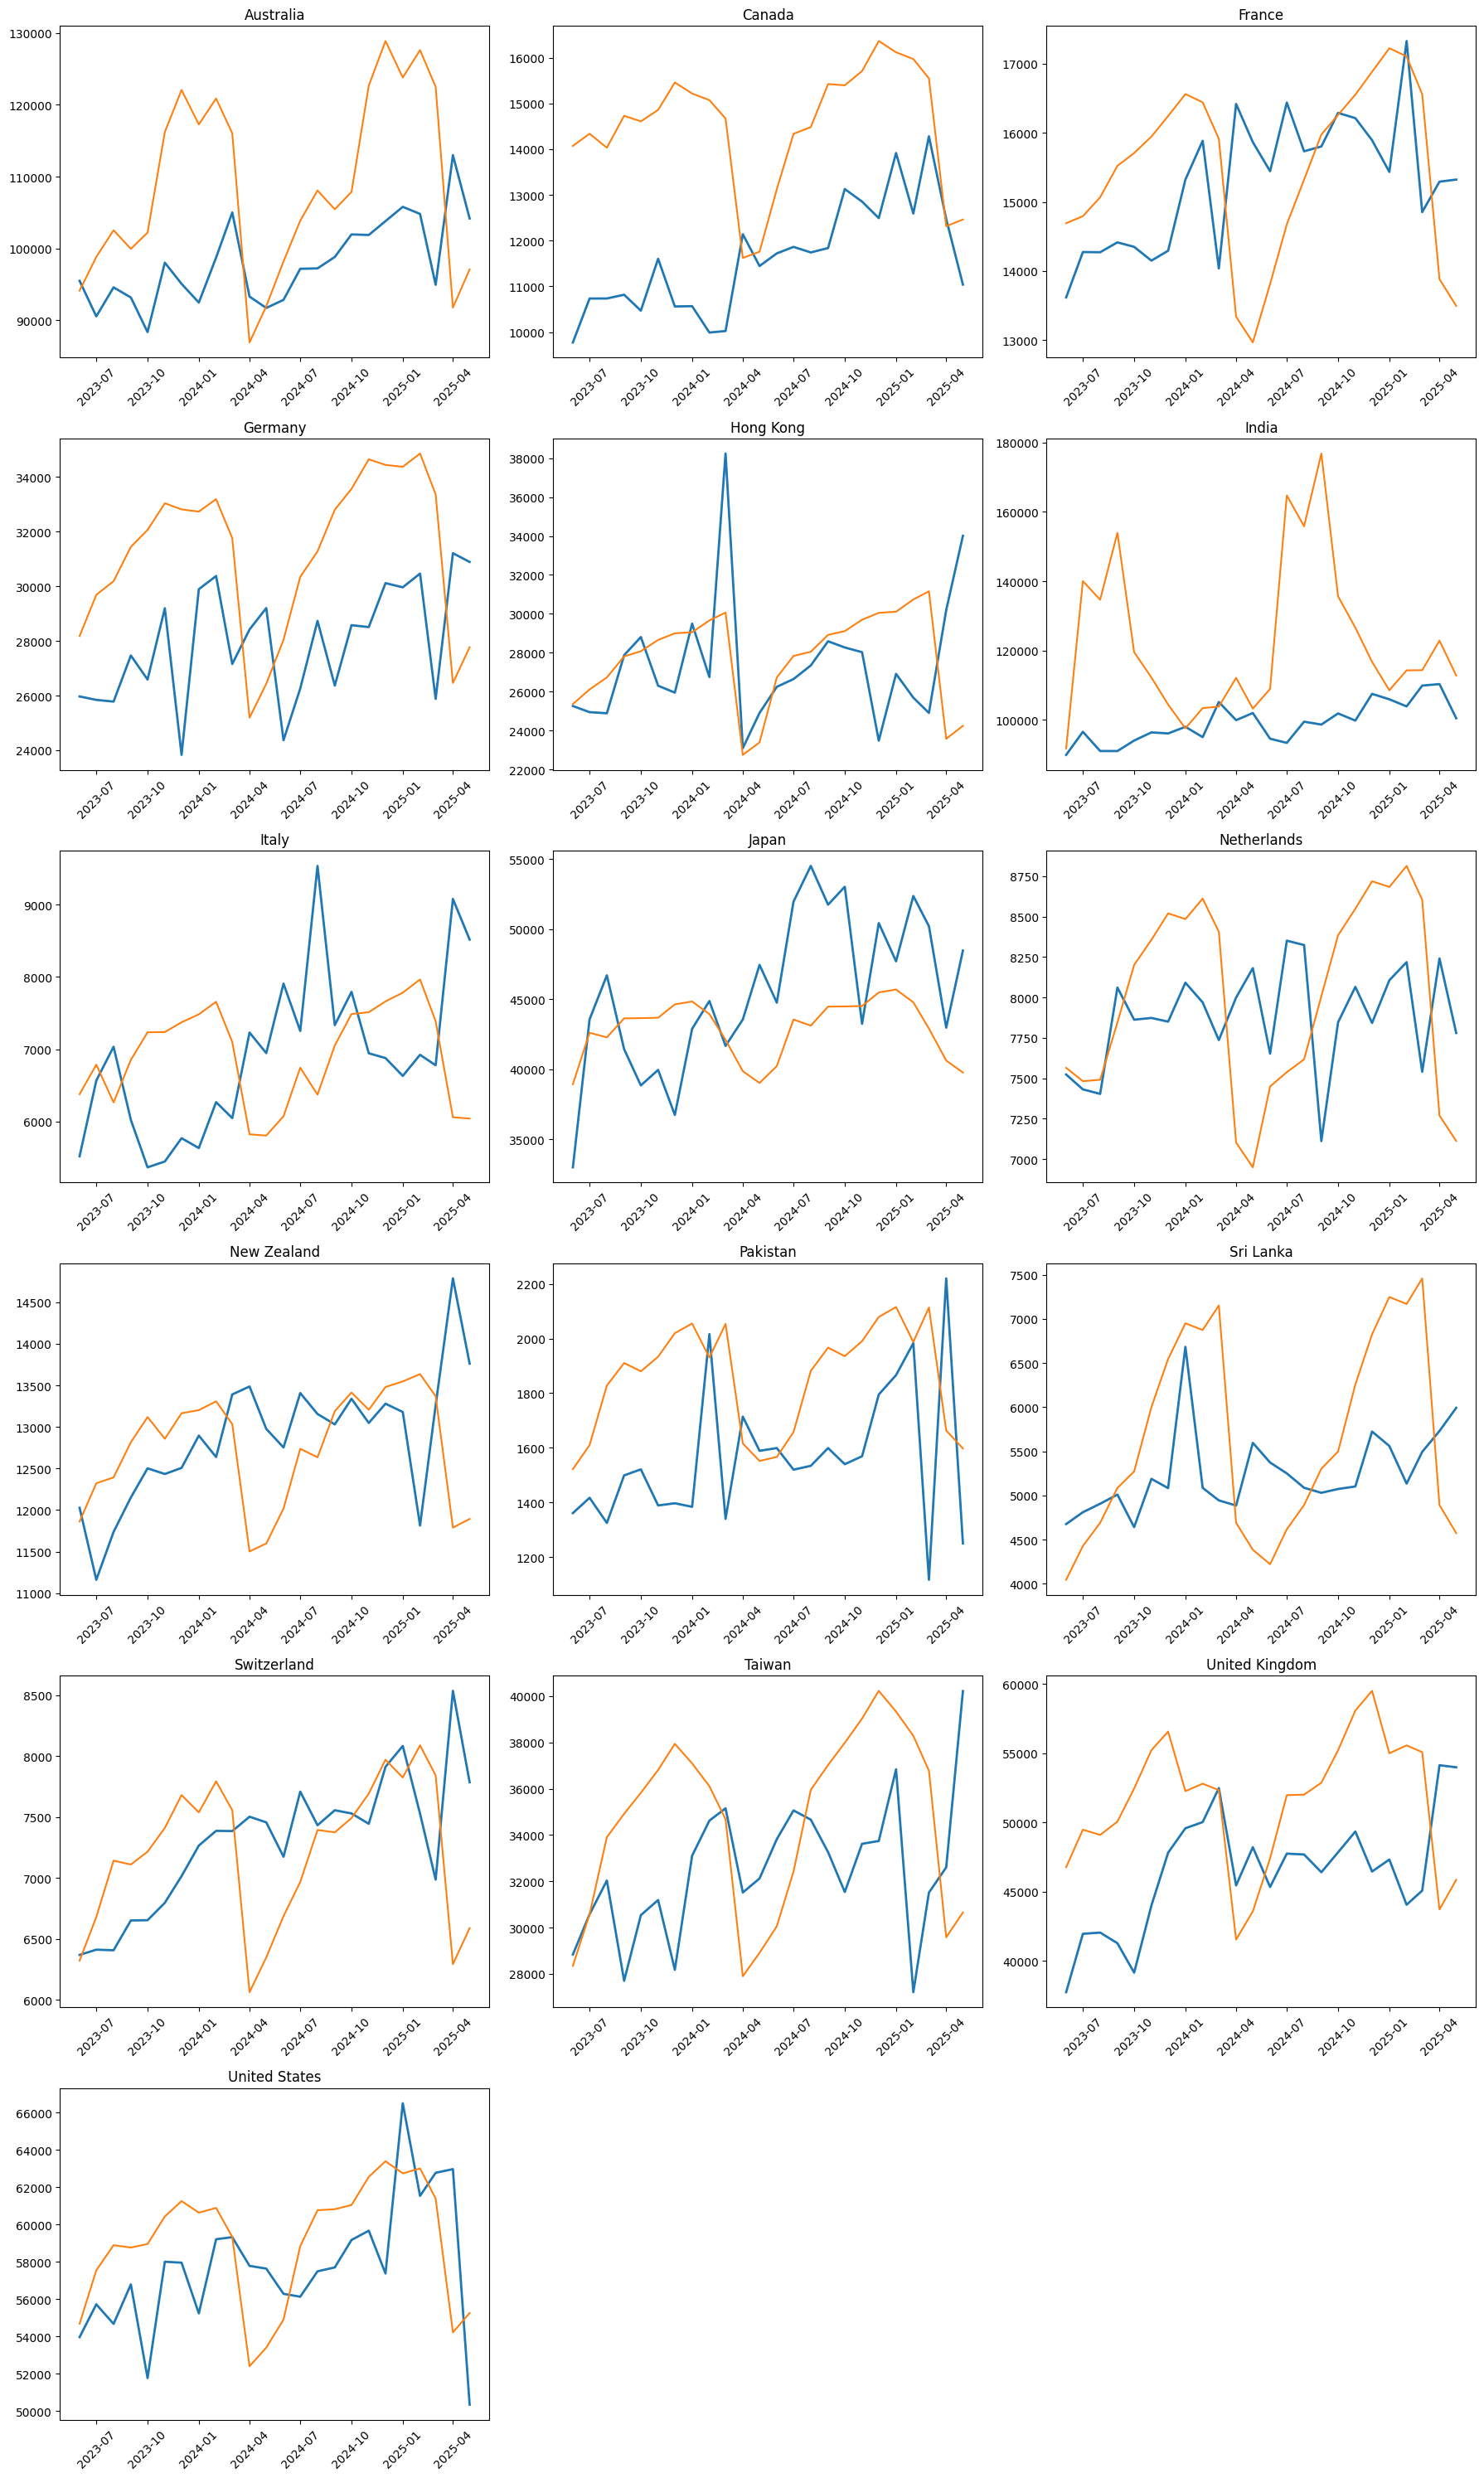

In [ ]:
countries = predictions_df["country"].unique()
n = len(countries)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    plot_df = predictions_df[predictions_df["country"] == country].sort_values("month")
    
    ax.plot(plot_df["month"], plot_df["actual"], label="Actual", linewidth=2)
    ax.plot(plot_df["month"], plot_df["predicted"], label="Predicted", linewidth=1.5)
    
    ax.set_title(country)
    ax.tick_params(axis='x', rotation=45)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()